# 16 — `BNet`: multi-modality wrapper around MNet1000

`scitex_nn.BNet_v1` chains per-modality `BHead`s (channel attention
+ 1×1 → `N_VIRTUAL_CHS` virtual channels) with a shared MNet1000
backbone and per-modality classifier heads. Forward signature:
`model(x, i_head)`.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

import scitex_nn

torch.manual_seed(0)
batch, seq_len = 1, 1000  # MNet1000's hardcoded N_FC_IN requires seq_len = 1000
n_chs_eeg, n_chs_meg = 19, 32
n_classes_eeg, n_classes_meg = 4, 2

## Build a 2-modality BNet

In [2]:
BNet_config = {
    "n_bands": 6,
    "SAMP_RATE": 250,
    "n_chs": [n_chs_eeg, n_chs_meg],
    "n_classes": [n_classes_eeg, n_classes_meg],
    "n_fc1": 1024,
    "d_ratio1": 0.5,
    "n_fc2": 256,
    "d_ratio2": 0.5,
}
MNet_config = {
    "classes": list(range(max(n_classes_eeg, n_classes_meg))),
    "n_chs": 32,
    "n_fc1": 1024,
    "d_ratio1": 0.5,
    "n_fc2": 256,
    "d_ratio2": 0.5,
}
model = scitex_nn.BNet_v1(BNet_config, MNet_config)
n_total = sum(p.numel() for p in model.parameters())
print(f"BNet_v1 — {n_total:,} parameters total")

BNet_v1 — 17,154,623 parameters total


## Forward each head + cross-entropy backward

In [3]:
x_eeg = torch.randn(batch, n_chs_eeg, seq_len)
x_meg = torch.randn(batch, n_chs_meg, seq_len)
y_eeg = model(x_eeg, i_head=0)
y_meg = model(x_meg, i_head=1)
print("EEG head:", tuple(y_eeg.shape), "| MEG head:", tuple(y_meg.shape))

loss = nn.functional.cross_entropy(
    y_eeg, torch.zeros(batch, dtype=torch.long)
) + nn.functional.cross_entropy(y_meg, torch.zeros(batch, dtype=torch.long))
loss.backward()
print(f"loss = {loss.item():.3f}")

EEG head: (1, 4) | MEG head: (1, 2)


loss = 2.240


## Parameter distribution per submodule

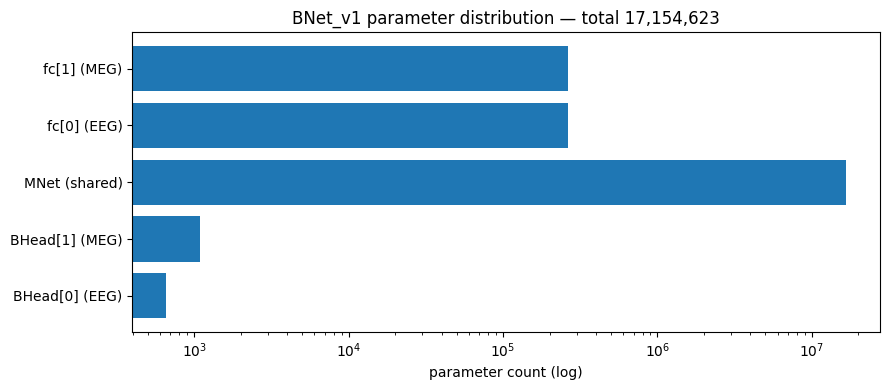

In [4]:
submodules = {
    "BHead[0] (EEG)": model.heads[0],
    "BHead[1] (MEG)": model.heads[1],
    "MNet (shared)": model.MNet,
    "fc[0] (EEG)": model.fcs[0],
    "fc[1] (MEG)": model.fcs[1],
}
counts = {
    name: sum(p.numel() for p in m.parameters()) for name, m in submodules.items()
}

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(list(counts.keys()), list(counts.values()))
ax.set_xscale("log")
ax.set_xlabel("parameter count (log)")
ax.set_title(f"BNet_v1 parameter distribution — total {n_total:,}")
fig.tight_layout()
plt.show()